# HADDOCK Energy Analysis - HADDOCK_results

Analysis of Electrostatic, Van der Waals, Desolvation, Non-bonded, and Total energies across HADDOCK runs in HADDOCK_results directory

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from itertools import combinations

plt.style.use('default')
plt.rcParams['figure.figsize'] = (20, 8)
plt.rcParams['font.size'] = 12

In [23]:
def read_haddock_energies(stat_file):
    """Read energy data from HADDOCK statistics file"""
    energy_data = []
    
    with open(stat_file, 'r') as f:
        lines = f.readlines()
        
        for line in lines[1:]:  # Skip header
            line = line.strip()
            if line and not line.startswith('#'):
                parts = line.split()
                if len(parts) >= 23:
                    try:
                        data = {
                            'Structure': parts[0],
                            'HADDOCK_Score': float(parts[1]),
                            'Enb': float(parts[4]),           # Non-bonded energy
                            'Evdw': float(parts[6]),          # Van der Waals energy
                            'Eelec': float(parts[7]),         # Electrostatic energy
                            'Edesolv': float(parts[22])       # Desolvation energy
                        }
                        
                        # Calculate total energy (sum of all 4 components)
                        data['Total_Energy'] = data['Enb'] + data['Evdw'] + data['Eelec'] + data['Edesolv']
                        
                        # Only include reasonable energies
                        if data['HADDOCK_Score'] < 1000:
                            energy_data.append(data)
                            
                    except (ValueError, IndexError):
                        continue
    
    return energy_data

In [24]:
# Define HADDOCK runs in HADDOCK_results directory
haddock_runs = {
    '672620-original_boltz2': 'Original Boltz2',
    '669247-4base_mismatch_boltz2': '4Base Mismatch Boltz2', 
    '668631-terminal_fold2': 'Terminal Fold2',
    '669245-scrambled_boltz2': 'Scrambled Boltz2'
}

# Load all data
all_data = []

print("📁 Loading HADDOCK data from HADDOCK_results...")
successful_runs = []

for folder, run_name in haddock_runs.items():
    stat_file = f'HADDOCK_results/{folder}/structures/it1/water/structures_air-sorted.stat'
    
    if os.path.exists(stat_file):
        energy_data = read_haddock_energies(stat_file)
        if len(energy_data) > 0:
            print(f"✅ {run_name}: {len(energy_data)} structures")
            successful_runs.append(run_name)
            
            for data in energy_data:
                data['Run_Name'] = run_name
                data['Run_ID'] = folder
                all_data.append(data)
        else:
            print(f"⚠️ {run_name}: No valid energy data found")
    else:
        print(f"⚠️ File not found: {stat_file}")

# Create DataFrame
df = pd.DataFrame(all_data)

# Show structure counts per run
print("\n📋 Structure counts:")
structure_counts = df.groupby('Run_Name').size().sort_values(ascending=False)
display(structure_counts.to_frame('Count'))

📁 Loading HADDOCK data from HADDOCK_results...
✅ Original Boltz2: 191 structures
✅ 4Base Mismatch Boltz2: 200 structures
✅ Terminal Fold2: 200 structures
✅ Scrambled Boltz2: 200 structures

📋 Structure counts:


,Count
Run_Name,
4Base Mismatch Boltz2,200
Scrambled Boltz2,200
Terminal Fold2,200
Original Boltz2,191


/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_5996/1229670442.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data,
/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_5996/1229670442.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data,
/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_5996/1229670442.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data,
/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_5996/1229670442.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename

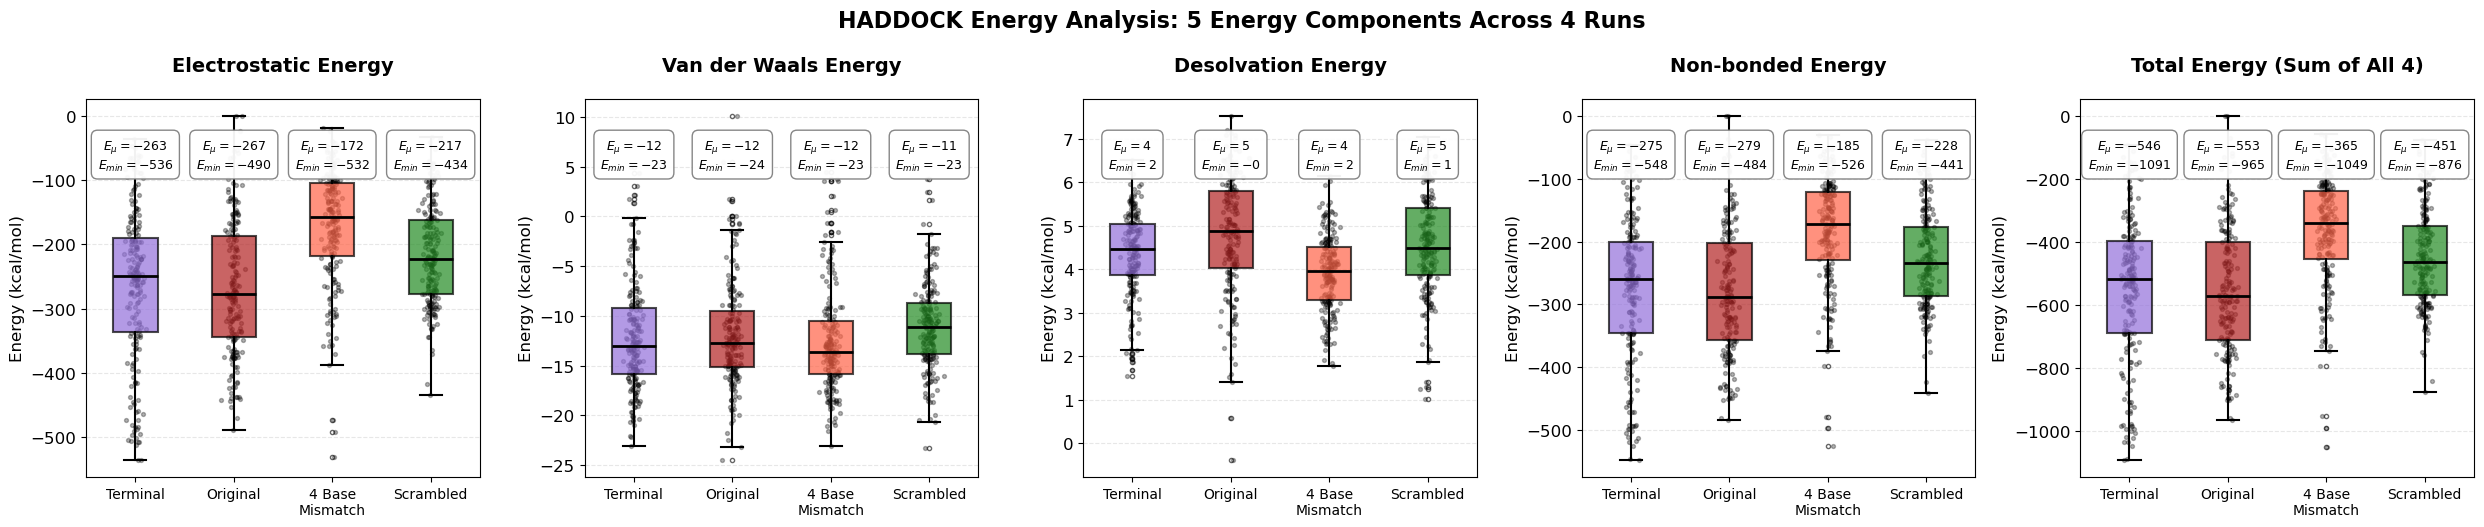

📊 Box plots generated with colors matching PDB structure screenshot!
💾 Saved as both PNG and PDF formats
🎨 Colors: Terminal=Purple, Original=Red, 4Base Mismatch=Orange, Scrambled=Green


In [25]:
# Define the 5 energy types for box plots
energy_types = {
    'Eelec': 'Electrostatic Energy',
    'Evdw': 'Van der Waals Energy', 
    'Edesolv': 'Desolvation Energy',
    'Enb': 'Non-bonded Energy',
    'Total_Energy': 'Total Energy (Sum of All 4)'
}

# Create 5 box plots in a single figure
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

# Color scheme matching the PDB structure screenshot
# Terminal=purple, Original=red, 4Base Mismatch=orange, Scrambled=green
colors = ['#9370DB', '#B22222', '#FF6347', '#228B22']  # Purple, Burgundy, Orange-Red, Forest Green

# NEW ORDER: Terminal, Original, 4Base Mismatch, Scrambled
run_order = ['Terminal Fold2', 'Original Boltz2', '4Base Mismatch Boltz2', 'Scrambled Boltz2']
category_labels = ['Terminal', 'Original', '4 Base\nMismatch', 'Scrambled']

for idx, (energy_col, energy_title) in enumerate(energy_types.items()):
    ax = axes[idx]
    
    # Prepare data for box plot
    box_data = []
    box_colors = []
    
    for i, run in enumerate(run_order):
        run_data = df[df['Run_Name'] == run][energy_col]
        if len(run_data) > 0:
            box_data.append(run_data)
            box_colors.append(colors[i])
    
    # Create box plot with category labels
    bp = ax.boxplot(box_data, 
                   labels=category_labels,
                   patch_artist=True,
                   boxprops=dict(linewidth=1.5),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   medianprops=dict(linewidth=2, color='black'),
                   flierprops=dict(marker='o', markersize=3, alpha=0.6))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    # Add scatter points
    for i, run in enumerate(run_order, 1):
        run_data = df[df['Run_Name'] == run][energy_col]
        if len(run_data) > 0:
            y = run_data.values
            x = np.random.normal(i, 0.04, size=len(y))
            ax.scatter(x, y, alpha=0.3, s=8, color='black')
    
    # Customize plot
    ax.set_title(f'{energy_title}', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('Energy (kcal/mol)', fontsize=12)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # NO rotation for x-axis labels, smaller font to prevent overlap
    ax.tick_params(axis='x', rotation=0, labelsize=10)
    
    # Add mean and min values together with better positioning
    for i, run in enumerate(run_order, 1):
        run_data = df[df['Run_Name'] == run][energy_col]
        if len(run_data) > 0:
            mean_val = run_data.mean()
            min_val = run_data.min()
            y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
            y_pos = ax.get_ylim()[1] - y_range * 0.15  # Even higher to avoid overlap
            
            # Use simple, clean notation that definitely renders
            text_content = f'$E_{{\\mu}}={mean_val:.0f}$\n$E_{{min}}={min_val:.0f}$'
            
            ax.text(i, y_pos, text_content,
                   ha='center', va='center', fontweight='bold', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                           alpha=0.95, edgecolor='gray', linewidth=1))

plt.suptitle('HADDOCK Energy Analysis: 5 Energy Components Across 4 Runs', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Even more space at bottom for two-line labels

# Save in both PNG and PDF formats
plt.savefig('HADDOCK_results_5_Energy_BoxPlots.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('HADDOCK_results_5_Energy_BoxPlots.pdf', bbox_inches='tight', facecolor='white')
plt.show()

print("📊 Box plots generated with colors matching PDB structure screenshot!")
print("💾 Saved as both PNG and PDF formats")
print("🎨 Colors: Terminal=Purple, Original=Red, 4Base Mismatch=Orange, Scrambled=Green")

In [26]:
# Statistical Analysis - P-value calculations between all pairs of runs
print("📈 Statistical Analysis: P-value calculations between runs")
print("=" * 70)

# Create a comprehensive p-value DataFrame
p_value_results = []

# Get all pairs of runs
run_pairs = list(combinations(run_order, 2))
print(f"Performing {len(run_pairs)} pairwise comparisons per energy type...")

for energy_col, energy_title in energy_types.items():
    print(f"\n🎯 {energy_title}:")
    print("-" * 50)
    
    for run1, run2 in run_pairs:
        data1 = df[df['Run_Name'] == run1][energy_col]
        data2 = df[df['Run_Name'] == run2][energy_col]
        
        if len(data1) > 0 and len(data2) > 0:
            # Perform t-test
            t_stat, p_val = stats.ttest_ind(data1, data2)
            
            # Store results
            p_value_results.append({
                'Energy_Type': energy_title,
                'Run_1': run1,
                'Run_2': run2,
                'P_Value': p_val,
                'Significant': 'Yes' if p_val < 0.05 else 'No',
                'Mean_1': data1.mean(),
                'Mean_2': data2.mean(),
                'Mean_Difference': abs(data1.mean() - data2.mean())
            })
            
            significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
            print(f"  {run1} vs {run2}: p = {p_val:.2e} {significance}")

# Create comprehensive p-value DataFrame
p_value_df = pd.DataFrame(p_value_results)

print(f"\n📊 Complete P-value Results:")
display(p_value_df.round(4))

📈 Statistical Analysis: P-value calculations between runs
Performing 6 pairwise comparisons per energy type...

🎯 Electrostatic Energy:
--------------------------------------------------
  Terminal Fold2 vs Original Boltz2: p = 7.50e-01 
  Terminal Fold2 vs 4Base Mismatch Boltz2: p = 1.18e-16 ***
  Terminal Fold2 vs Scrambled Boltz2: p = 4.61e-06 ***
  Original Boltz2 vs 4Base Mismatch Boltz2: p = 1.06e-19 ***
  Original Boltz2 vs Scrambled Boltz2: p = 1.23e-07 ***
  4Base Mismatch Boltz2 vs Scrambled Boltz2: p = 1.74e-07 ***

🎯 Van der Waals Energy:
--------------------------------------------------
  Terminal Fold2 vs Original Boltz2: p = 6.14e-01 
  Terminal Fold2 vs 4Base Mismatch Boltz2: p = 6.36e-01 
  Terminal Fold2 vs Scrambled Boltz2: p = 2.72e-02 *
  Original Boltz2 vs 4Base Mismatch Boltz2: p = 3.27e-01 
  Original Boltz2 vs Scrambled Boltz2: p = 9.49e-02 
  4Base Mismatch Boltz2 vs Scrambled Boltz2: p = 6.26e-03 **

🎯 Desolvation Energy:
------------------------------------

,Energy_Type,Run_1,Run_2,P_Value,Significant,Mean_1,Mean_2,Mean_Difference
0,Electrostatic Energy,Terminal Fold2,Original Boltz2,0.7496,No,-263.1953,-266.8096,3.6143
1,Electrostatic Energy,Terminal Fold2,4Base Mismatch Boltz2,0.0000,Yes,-263.1953,-172.2191,90.9761
2,Electrostatic Energy,Terminal Fold2,Scrambled Boltz2,0.0000,Yes,-263.1953,-216.8038,46.3915
3,Electrostatic Energy,Original Boltz2,4Base Mismatch Boltz2,0.0000,Yes,-266.8096,-172.2191,94.5904
4,Electrostatic Energy,Original Boltz2,Scrambled Boltz2,0.0000,Yes,-266.8096,-216.8038,50.0058
5,Electrostatic Energy,4Base Mismatch Boltz2,Scrambled Boltz2,0.0000,Yes,-172.2191,-216.8038,44.5847
6,Van der Waals Energy,Terminal Fold2,Original Boltz2,0.6141,No,-12.2056,-11.9292,0.2764
7,Van der Waals Energy,Terminal Fold2,4Base Mismatch Boltz2,0.6360,No,-12.2056,-12.4654,0.2599
8,Van der Waals Energy,Terminal Fold2,Scrambled Boltz2,0.0272,Yes,-12.2056,-11.1103,1.0952
9,Van der Waals Energy,Original Boltz2,4Base Mismatch Boltz2,0.3272,No,-11.9292,-12.4654,0.5362


In [27]:
# Create summary statistics table
print("📊 Summary Statistics for All Energy Types")
print("=" * 60)

summary_stats = []

for energy_col, energy_title in energy_types.items():
    for run in run_order:
        run_data = df[df['Run_Name'] == run][energy_col]
        if len(run_data) > 0:
            summary_stats.append({
                'Energy_Type': energy_title,
                'Run_Name': run,
                'Count': len(run_data),
                'Mean': run_data.mean(),
                'Std': run_data.std(),
                'Min': run_data.min(),
                'Max': run_data.max(),
                'Median': run_data.median()
            })

summary_df = pd.DataFrame(summary_stats)

# Show ranking by energy type (best = most negative)
print("\n🏆 ENERGY RANKINGS (Most Negative = Best Binding):")
print("=" * 60)

for energy_col, energy_title in energy_types.items():
    print(f"\n🎯 {energy_title}:")
    ranking_data = summary_df[summary_df['Energy_Type'] == energy_title].copy()
    ranking_data = ranking_data.sort_values('Mean')  # Most negative first
    
    for i, row in enumerate(ranking_data.itertuples(), 1):
        print(f"  {i}. {row.Run_Name:<25}: {row.Mean:8.1f} kcal/mol (n={row.Count})")

# Display full summary table
print("\n📊 Complete Summary Statistics:")
display(summary_df.round(2))

# Save results
summary_df.to_csv('HADDOCK_results_Energy_Summary_Stats.csv', index=False)
p_value_df.to_csv('HADDOCK_results_Energy_PValues.csv', index=False)

# Save significant results only
significant_results = p_value_df[p_value_df['Significant'] == 'Yes'].copy()
significant_results = significant_results.sort_values('P_Value')
significant_results.to_csv('HADDOCK_results_Significant_PValues.csv', index=False)

print("\n💾 Files Saved:")
print("  📊 HADDOCK_results_5_Energy_BoxPlots.png")
print("  📊 HADDOCK_results_Energy_Summary_Stats.csv")
print("  📊 HADDOCK_results_Energy_PValues.csv")
print("  📊 HADDOCK_results_Significant_PValues.csv (p < 0.05 only)")
print(f"\n✨ Analysis Complete!")
print(f"📊 Total structures analyzed: {len(df)}")
print(f"📊 Significant comparisons: {len(significant_results)} out of {len(p_value_df)}")

📊 Summary Statistics for All Energy Types

🏆 ENERGY RANKINGS (Most Negative = Best Binding):

🎯 Electrostatic Energy:
  1. Original Boltz2          :   -266.8 kcal/mol (n=191)
  2. Terminal Fold2           :   -263.2 kcal/mol (n=200)
  3. Scrambled Boltz2         :   -216.8 kcal/mol (n=200)
  4. 4Base Mismatch Boltz2    :   -172.2 kcal/mol (n=200)

🎯 Van der Waals Energy:
  1. 4Base Mismatch Boltz2    :    -12.5 kcal/mol (n=200)
  2. Terminal Fold2           :    -12.2 kcal/mol (n=200)
  3. Original Boltz2          :    -11.9 kcal/mol (n=191)
  4. Scrambled Boltz2         :    -11.1 kcal/mol (n=200)

🎯 Desolvation Energy:
  1. 4Base Mismatch Boltz2    :      3.9 kcal/mol (n=200)
  2. Terminal Fold2           :      4.3 kcal/mol (n=200)
  3. Scrambled Boltz2         :      4.5 kcal/mol (n=200)
  4. Original Boltz2          :      4.8 kcal/mol (n=191)

🎯 Non-bonded Energy:
  1. Original Boltz2          :   -278.7 kcal/mol (n=191)
  2. Terminal Fold2           :   -275.4 kcal/mol (n=200)


,Energy_Type,Run_Name,Count,Mean,Std,Min,Max,Median
0,Electrostatic Energy,Terminal Fold2,200,-263.20,118.23,-535.62,-35.94,-248.96
1,Electrostatic Energy,Original Boltz2,191,-266.81,104.77,-489.82,0.00,-277.06
2,Electrostatic Energy,4Base Mismatch Boltz2,200,-172.22,89.93,-531.87,-18.80,-157.78
3,Electrostatic Energy,Scrambled Boltz2,200,-216.80,77.22,-434.47,-32.64,-222.07
4,Van der Waals Energy,Terminal Fold2,200,-12.21,5.50,-23.13,5.01,-13.01
5,Van der Waals Energy,Original Boltz2,191,-11.93,5.32,-24.48,10.09,-12.75
6,Van der Waals Energy,4Base Mismatch Boltz2,200,-12.47,5.48,-23.07,5.51,-13.62
7,Van der Waals Energy,Scrambled Boltz2,200,-11.11,4.32,-23.26,3.80,-11.16
8,Desolvation Energy,Terminal Fold2,200,4.34,0.97,1.54,6.51,4.46
9,Desolvation Energy,Original Boltz2,191,4.77,1.36,-0.38,7.52,4.87



💾 Files Saved:
  📊 HADDOCK_results_5_Energy_BoxPlots.png
  📊 HADDOCK_results_Energy_Summary_Stats.csv
  📊 HADDOCK_results_Energy_PValues.csv
  📊 HADDOCK_results_Significant_PValues.csv (p < 0.05 only)

✨ Analysis Complete!
📊 Total structures analyzed: 791
📊 Significant comparisons: 21 out of 30


In [28]:
# Quick visualization of energy differences from Original
print("🎯 ENERGY DIFFERENCES FROM ORIGINAL BOLTZ2")
print("=" * 50)

# Get Original Boltz2 means as reference
original_means = {}
for energy_col, energy_title in energy_types.items():
    original_data = df[df['Run_Name'] == 'Original Boltz2'][energy_col]
    if len(original_data) > 0:
        original_means[energy_col] = original_data.mean()

# Calculate differences from original
differences_data = []
for energy_col, energy_title in energy_types.items():
    for run in run_order:
        if run != 'Original Boltz2':
            run_data = df[df['Run_Name'] == run][energy_col]
            if len(run_data) > 0 and energy_col in original_means:
                mean_diff = run_data.mean() - original_means[energy_col]
                differences_data.append({
                    'Energy_Type': energy_title,
                    'Run_Name': run,
                    'Difference_from_Original': mean_diff
                })

diff_df = pd.DataFrame(differences_data)

if not diff_df.empty:
    print("\nDifferences from Original Boltz2 (Positive = Less Favorable):")
    for energy_title in energy_types.values():
        print(f"\n{energy_title}:")
        energy_diff = diff_df[diff_df['Energy_Type'] == energy_title]
        for _, row in energy_diff.iterrows():
            direction = "worse" if row['Difference_from_Original'] > 0 else "better"
            print(f"  {row['Run_Name']:<25}: {row['Difference_from_Original']:+8.1f} kcal/mol ({direction})")

print("\n🧬 This analysis shows how much each perturbation affects binding energy!")

🎯 ENERGY DIFFERENCES FROM ORIGINAL BOLTZ2

Differences from Original Boltz2 (Positive = Less Favorable):

Electrostatic Energy:
  Terminal Fold2           :     +3.6 kcal/mol (worse)
  4Base Mismatch Boltz2    :    +94.6 kcal/mol (worse)
  Scrambled Boltz2         :    +50.0 kcal/mol (worse)

Van der Waals Energy:
  Terminal Fold2           :     -0.3 kcal/mol (better)
  4Base Mismatch Boltz2    :     -0.5 kcal/mol (better)
  Scrambled Boltz2         :     +0.8 kcal/mol (worse)

Desolvation Energy:
  Terminal Fold2           :     -0.4 kcal/mol (better)
  4Base Mismatch Boltz2    :     -0.8 kcal/mol (better)
  Scrambled Boltz2         :     -0.2 kcal/mol (better)

Non-bonded Energy:
  Terminal Fold2           :     +3.3 kcal/mol (worse)
  4Base Mismatch Boltz2    :    +94.1 kcal/mol (worse)
  Scrambled Boltz2         :    +50.8 kcal/mol (worse)

Total Energy (Sum of All 4):
  Terminal Fold2           :     +6.2 kcal/mol (worse)
  4Base Mismatch Boltz2    :   +187.3 kcal/mol (worse)
  S